Enunciado:

Trabalho em grupo - Siga as instruções em anexo.

Contexto do estudo (fornecido pelo professor):

Estudo de medidas repetidas com n = 120 blocos agrícolas. Cada bloco (unidade experimental) contém subparcelas submetidas aos quatro tratamentos formados pela combinação de dois fatores:

- **Fator 1 - Irrigação**: dois níveis, *reduzida* e *adequada*;
- **Fator 2 - Biofertilizante**: dois níveis, *sem biofertilizante* e *com biofertilizante*.

A variável resposta quantitativa é a **produtividade de milho**, medida em sacas por hectare. O objetivo é avaliar se a irrigação, o biofertilizante e a interação entre esses fatores alteram a produtividade média.

1. **Análise descritiva inicial dos dados.**

O primeiro integrante do grupo deverá apresentar uma descrição inicial da base de
dados. Essa análise deve incluir:

(a) uma breve descrição do contexto da base de dados;

(b) identificação das variáveis quantitativas e categóricas que serão utilizadas na análise
e o(s) tratamento(s) considerados;

(c) cálculo e interpretação do vetor de médias amostrais;

(d) Gráfico de linhas: considere os dois fatores da base, cada um com dois níveis, e
a variável resposta quantitativa observada sob os quatro tratamentos formados
pelas combinações desses fatores. Produza um gráfico de linhas para descrever
o comportamento da resposta ao longo dos tratamentos. No eixo horizontal,
represente os níveis de um dos fatores; no eixo vertical, represente os valores
observados da variável resposta. Use linhas distintas para representar os níveis
do outro fator. Inicialmente, construa o gráfico utilizando as médias amostrais da
resposta em cada combinação dos fatores, de modo a visualizar os efeitos principais
e uma possível interação entre eles. Em seguida, se julgar conveniente, acrescente
ou apresente separadamente os perfis individuais das unidades experimentais,
lembrando que cada unidade foi observada sob os quatro tratamentos. Interprete o
gráfico comentando se há evidência visual de efeito principal do primeiro fator, efeito
principal do segundo fator e interação entre os fatores. Em particular, observe se uma
mudança no nível de um fator altera sistematicamente a resposta, se o outro fator
também altera a resposta e se as linhas aproximadamente paralelas ou não paralelas
sugerem ausência ou presença de interação.

### *(a) uma breve descrição do contexto da base de dados;*

A base de dados referente ao trabalho é um arquivo .csv cujo nome é "produtividade_milho" disponibilizado pelo professor.

O arquivo está em formato longo e contém 480 linhas, correspondentes a 120 blocos agrícolas (unidades experimentais) observados sob os 4 tratamentos formados pela combinação de dois fatores: irrigação (reduzida/adequada) e biofertilizante (sem/com biofertilizante). Cada linha traz o bloco, o nível de cada fator, o rótulo do tratamento (combinação dos dois fatores) e a produtividade de milho observada (sacas por hectare).

Trata-se de um delineamento em blocos com **medidas repetidas**: cada bloco é observado sob os 4 tratamentos, o que caracteriza um experimento fatorial 2x2 com blocagem. O objetivo é avaliar se a irrigação, o biofertilizante e a interação entre esses fatores alteram a produtividade média de milho.

Iremos usar ferramentas estatísticas (vetor de médias, gráficos de perfis/interação e, posteriormente, testes de hipótese para medidas repetidas / ANOVA) para responder a essa pergunta.

In [3]:
dados <- read.csv("produtividade_milho.csv")

dados$irrigacao <- factor(dados$irrigacao, levels = c("reduzida", "adequada"))
dados$biofertilizante <- factor(dados$biofertilizante, levels = c("sem_biofertilizante", "com_biofertilizante"))
dados$tratamento <- factor(dados$tratamento, levels = c("reduzida_sem_biofertilizante",
                                                          "reduzida_com_biofertilizante",
                                                          "adequada_sem_biofertilizante",
                                                          "adequada_com_biofertilizante"))

head(dados)


,bloco,irrigacao,biofertilizante,tratamento,produtividade_sacas_ha
,<chr>,<fct>,<fct>,<fct>,<dbl>
1,Bloco_001,reduzida,sem_biofertilizante,reduzida_sem_biofertilizante,57.59
2,Bloco_001,reduzida,com_biofertilizante,reduzida_com_biofertilizante,65.02
3,Bloco_001,adequada,sem_biofertilizante,adequada_sem_biofertilizante,66.26
4,Bloco_001,adequada,com_biofertilizante,adequada_com_biofertilizante,70.77
5,Bloco_002,reduzida,sem_biofertilizante,reduzida_sem_biofertilizante,44.32
6,Bloco_002,reduzida,com_biofertilizante,reduzida_com_biofertilizante,42.57


In [4]:
str(dados)
summary(dados)


'data.frame':	480 obs. of  5 variables:
 $ bloco                 : chr  "Bloco_001" "Bloco_001" "Bloco_001" "Bloco_001" ...
 $ irrigacao             : Factor w/ 2 levels "reduzida","adequada": 1 1 2 2 1 1 2 2 1 1 ...
 $ biofertilizante       : Factor w/ 2 levels "sem_biofertilizante",..: 1 2 1 2 1 2 1 2 1 2 ...
 $ tratamento            : Factor w/ 4 levels "reduzida_sem_biofertilizante",..: 1 2 3 4 1 2 3 4 1 2 ...
 $ produtividade_sacas_ha: num  57.6 65 66.3 70.8 44.3 ...


    bloco              irrigacao              biofertilizante
 Length:480         reduzida:240   sem_biofertilizante:240   
 Class :character   adequada:240   com_biofertilizante:240   
 Mode  :character                                            
                                                             
                                                             
                                                             
                        tratamento  produtividade_sacas_ha
 reduzida_sem_biofertilizante:120   Min.   :36.88         
 reduzida_com_biofertilizante:120   1st Qu.:53.73         
 adequada_sem_biofertilizante:120   Median :60.52         
 adequada_com_biofertilizante:120   Mean   :60.98         
                                    3rd Qu.:67.84         
                                    Max.   :88.86         

In [5]:
# Checagem do delineamento: cada bloco deve aparecer exatamente uma vez em cada um dos 4 tratamentos
table(dados$irrigacao, dados$biofertilizante)
length(unique(dados$bloco))


          
           sem_biofertilizante com_biofertilizante
  reduzida                 120                 120
  adequada                 120                 120

[1] 120

### *(b) identificação das variáveis quantitativas e categóricas que serão utilizadas na análise e o(s) tratamento(s) considerados;*

**Variável quantitativa (resposta):**

- "produtividade_sacas_ha": produtividade de milho, em sacas por hectare.

**Variáveis categóricas (fatores / identificadores):**

- "bloco": identificador da unidade experimental (fator de blocagem), com 120 níveis;
- "irrigacao": fator 1, com 2 níveis (reduzida / adequada);
- "biofertilizante": fator 2, com 2 níveis (sem biofertilizante / com biofertilizante);
- "tratamento": variável categórica derivada, que rotula a combinação de irrigação x biofertilizante em cada linha (4 níveis).

**Tratamentos considerados:**

O experimento é fatorial 2x2, gerando 4 tratamentos, aos quais cada um dos 120 blocos foi submetido (medidas repetidas):

$T_1$: irrigação reduzida, sem biofertilizante

$T_2$: irrigação reduzida, com biofertilizante

$T_3$: irrigação adequada, sem biofertilizante

$T_4$: irrigação adequada, com biofertilizante

Chamando de $X_{kj}$ a produtividade do bloco $j$ no tratamento $k$ ($k = 1,2,3,4$), o vetor de observações de cada bloco é $\boldsymbol{X}_j = (X_{1j}, X_{2j}, X_{3j}, X_{4j})'$, $j = 1, \dots, 120$.

### *(c) cálculo e interpretação do vetor de médias amostrais;*

Para calcular o vetor de médias amostrais, reorganiza-se a base do formato longo (uma linha por bloco-tratamento) para o formato largo (uma linha por bloco, uma coluna por tratamento), e em seguida calcula-se a média de cada coluna.

In [6]:
library(tidyr)

dados_largo <- pivot_wider(dados,
                            id_cols = bloco,
                            names_from = tratamento,
                            values_from = produtividade_sacas_ha)

head(dados_largo)


bloco,reduzida_sem_biofertilizante,reduzida_com_biofertilizante,adequada_sem_biofertilizante,adequada_com_biofertilizante
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Bloco_001,57.59,65.02,66.26,70.77
Bloco_002,44.32,42.57,54.72,65.69
Bloco_003,59.11,60.49,69.28,75.33
Bloco_004,36.88,51.03,48.29,70.19
Bloco_005,63.70,72.65,78.05,83.61
Bloco_006,52.31,57.89,62.07,78.48


In [7]:
Xbar <- colMeans(dados_largo[,-1])
Xbar


reduzida_sem_biofertilizante reduzida_com_biofertilizante 
                    52.16958                     57.81708 
adequada_sem_biofertilizante adequada_com_biofertilizante 
                    62.03475                     71.90775

In [8]:
cat("Interpretação:\n\n")
cat(sprintf("- Xbar_1 (Reduzida / Sem biofertilizante)  = %.3f sacas/ha\n", Xbar[1]))
cat(sprintf("- Xbar_2 (Reduzida / Com biofertilizante)  = %.3f sacas/ha\n", Xbar[2]))
cat(sprintf("- Xbar_3 (Adequada / Sem biofertilizante)  = %.3f sacas/ha\n", Xbar[3]))
cat(sprintf("- Xbar_4 (Adequada / Com biofertilizante)  = %.3f sacas/ha\n\n", Xbar[4]))
cat(sprintf("Com base na amostra de 120 blocos, estima-se que a produtividade média de milho da população em estudo varie de %.3f sacas/ha (tratamento com pior desempenho médio) até %.3f sacas/ha (tratamento com melhor desempenho médio), a depender da combinação de irrigação e biofertilizante aplicada.\n",
            min(Xbar), max(Xbar)))


Interpretação:

- Xbar_1 (Reduzida / Sem biofertilizante)  = 52.170 sacas/ha
- Xbar_2 (Reduzida / Com biofertilizante)  = 57.817 sacas/ha
- Xbar_3 (Adequada / Sem biofertilizante)  = 62.035 sacas/ha
- Xbar_4 (Adequada / Com biofertilizante)  = 71.908 sacas/ha

Com base na amostra de 120 blocos, estima-se que a produtividade média de milho da população em estudo varie de 52.170 sacas/ha (tratamento com pior desempenho médio) até 71.908 sacas/ha (tratamento com melhor desempenho médio), a depender da combinação de irrigação e biofertilizante aplicada.


### *(d) Gráfico de linhas: efeitos principais e interação entre irrigação e biofertilizante;*

Serão construídos dois gráficos:

1. um gráfico de linhas com as **médias amostrais** da produtividade em cada combinação dos fatores (irrigação no eixo horizontal, uma linha para cada nível de biofertilizante), para visualizar os efeitos principais e uma possível interação;
2. o mesmo gráfico acrescido dos **perfis individuais** de cada bloco (uma linha fina por bloco, ligando sua produtividade sob irrigação reduzida à produtividade sob irrigação adequada), separados por nível de biofertilizante.

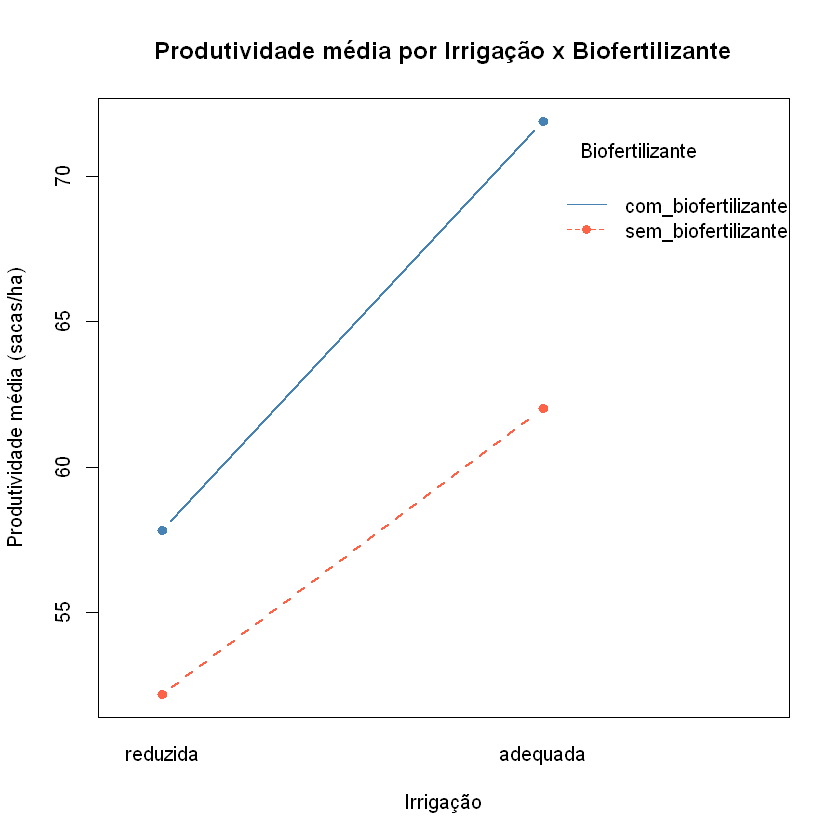

In [9]:
# Gráfico 1: médias amostrais por combinação de fatores
interaction.plot(x.factor = dados$irrigacao,
                  trace.factor = dados$biofertilizante,
                  response = dados$produtividade_sacas_ha,
                  fun = mean,
                  type = "b", pch = 19, lwd = 2,
                  col = c("tomato", "steelblue"),
                  xlab = "Irrigação",
                  ylab = "Produtividade média (sacas/ha)",
                  trace.label = "Biofertilizante",
                  main = "Produtividade média por Irrigação x Biofertilizante")


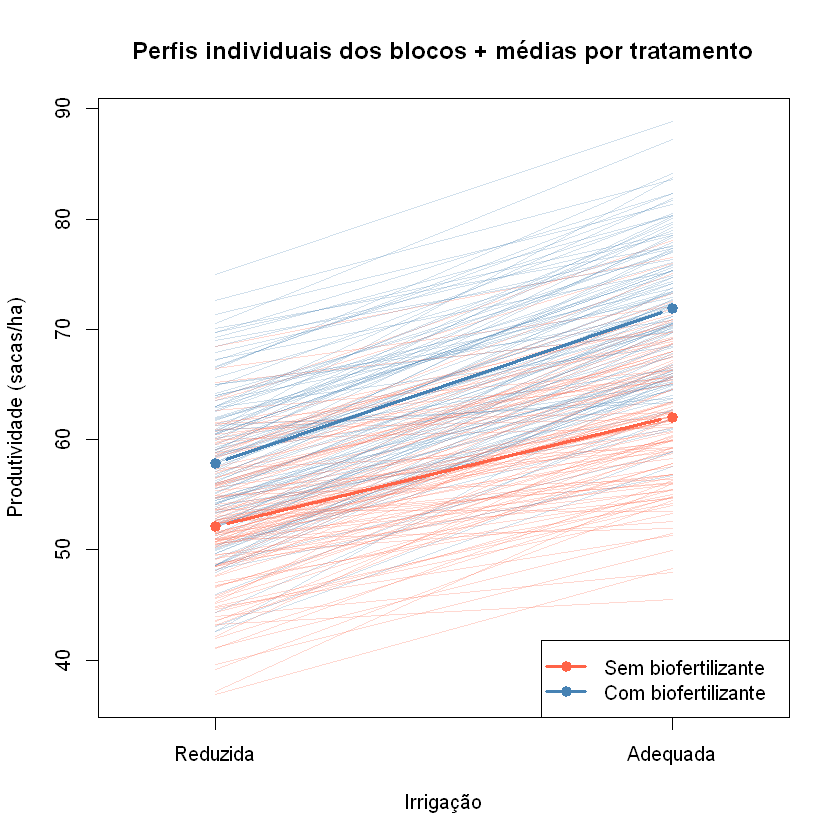

In [13]:
# Gráfico 2: perfis individuais dos blocos + médias sobrepostas
perfis <- pivot_wider(dados,
                       id_cols = c(bloco, biofertilizante),
                       names_from = irrigacao,
                       values_from = produtividade_sacas_ha)

cor_bloco <- ifelse(perfis$biofertilizante == "sem_biofertilizante", "tomato", "steelblue")

plot(NA, xlim = c(0.8, 2.2), ylim = range(dados$produtividade_sacas_ha),
     xaxt = "n", xlab = "Irrigação", ylab = "Produtividade (sacas/ha)",
     main = "Perfis individuais dos blocos + médias por tratamento")
axis(1, at = c(1, 2), labels = c("Reduzida", "Adequada"))

for (i in 1:nrow(perfis)) {
  lines(c(1, 2), c(perfis$reduzida[i], perfis$adequada[i]),
        col = adjustcolor(cor_bloco[i], alpha.f = 0.25))
}

medias <- aggregate(produtividade_sacas_ha ~ irrigacao + biofertilizante, data = dados, FUN = mean)
medias_sem <- medias[medias$biofertilizante == "sem_biofertilizante", ]
medias_com <- medias[medias$biofertilizante == "com_biofertilizante", ]
medias_sem <- medias_sem[order(medias_sem$irrigacao), ]
medias_com <- medias_com[order(medias_com$irrigacao), ]

lines(c(1, 2), medias_sem$produtividade_sacas_ha, col = "tomato", lwd = 3, type = "b", pch = 19)
lines(c(1, 2), medias_com$produtividade_sacas_ha, col = "steelblue", lwd = 3, type = "b", pch = 19)

legend("bottomright", legend = c("Sem biofertilizante", "Com biofertilizante"),
       col = c("tomato", "steelblue"), lty = 1, lwd = 3, pch = 19)


In [11]:
cat("Interpretação:\n\n")

media_irrig <- aggregate(produtividade_sacas_ha ~ irrigacao, data = dados, FUN = mean)
media_biof  <- aggregate(produtividade_sacas_ha ~ biofertilizante, data = dados, FUN = mean)

efeito_irrig <- diff(media_irrig$produtividade_sacas_ha)
efeito_biof  <- diff(media_biof$produtividade_sacas_ha)

diff_sem <- medias_sem$produtividade_sacas_ha[2] - medias_sem$produtividade_sacas_ha[1]
diff_com <- medias_com$produtividade_sacas_ha[2] - medias_com$produtividade_sacas_ha[1]
interacao <- diff_com - diff_sem

cat(sprintf("- Efeito principal da irrigacao: passar de reduzida para adequada altera a produtividade média em %.3f sacas/ha (em %s), %s\n\n",
            efeito_irrig, ifelse(efeito_irrig > 0, "aumento", "redução"),
            ifelse(abs(efeito_irrig) > 2, "o que sugere um efeito principal visualmente relevante da irrigação.", "o que sugere um efeito principal pequeno da irrigação.")))

cat(sprintf("- Efeito principal do biofertilizante: usar biofertilizante altera a produtividade média em %.3f sacas/ha (em %s), %s\n\n",
            efeito_biof, ifelse(efeito_biof > 0, "aumento", "redução"),
            ifelse(abs(efeito_biof) > 2, "o que sugere um efeito principal visualmente relevante do biofertilizante.", "o que sugere um efeito principal pequeno do biofertilizante.")))

cat(sprintf("- Possível interação: sob 'sem biofertilizante', mudar de irrigação reduzida para adequada altera a produtividade em %.3f sacas/ha; sob 'com biofertilizante', essa mudança é de %.3f sacas/ha. A diferença entre esses dois efeitos (medida de interação) é de %.3f sacas/ha, %s\n",
            diff_sem, diff_com, interacao,
            ifelse(abs(interacao) > 2,
                   "o que sugere que as linhas do gráfico não são paralelas, i.e., há indício visual de interação entre irrigação e biofertilizante (o efeito de um fator depende do nível do outro).",
                   "o que sugere que as linhas do gráfico são aproximadamente paralelas, i.e., há pouco indício visual de interação entre irrigação e biofertilizante (os efeitos dos fatores parecem aditivos).")))

cat("\nEssas conclusões são descritivas, baseadas apenas na inspeção visual das médias e dos perfis; a confirmação formal de efeitos principais e de interação deve ser feita posteriormente por meio de testes de hipótese apropriados (ex.: ANOVA para medidas repetidas / modelo com blocos).\n")


Interpretação:



- Efeito principal da irrigacao: passar de reduzida para adequada altera a produtividade média em 11.978 sacas/ha (em aumento), o que sugere um efeito principal visualmente relevante da irrigação.

- Efeito principal do biofertilizante: usar biofertilizante altera a produtividade média em 7.760 sacas/ha (em aumento), o que sugere um efeito principal visualmente relevante do biofertilizante.

- Possível interação: sob 'sem biofertilizante', mudar de irrigação reduzida para adequada altera a produtividade em 9.865 sacas/ha; sob 'com biofertilizante', essa mudança é de 14.091 sacas/ha. A diferença entre esses dois efeitos (medida de interação) é de 4.225 sacas/ha, o que sugere que as linhas do gráfico não são paralelas, i.e., há indício visual de interação entre irrigação e biofertilizante (o efeito de um fator depende do nível do outro).

Essas conclusões são descritivas, baseadas apenas na inspeção visual das médias e dos perfis; a confirmação formal de efeitos principais e de interação